## Emotion Classification with RNNs, LSTMs & GRUs

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

## LOADING THE DATASET FROM HUGGINFACE


In [59]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [60]:
label_names = emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [61]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [62]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [63]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## Exploratory Data Analysis (EDA)

<Axes: xlabel='label', ylabel='count'>

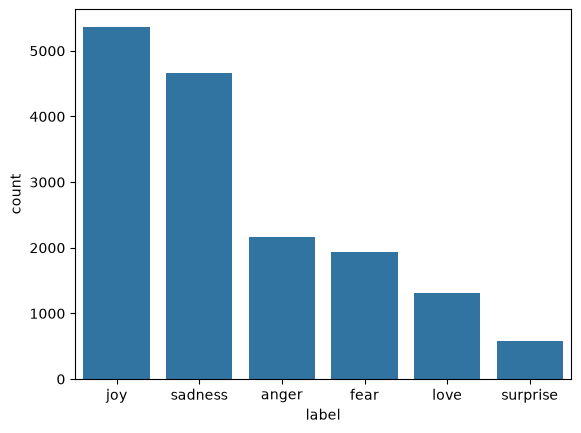

In [64]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [65]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

The dataset exhibits a significant class imbalance, dominated by positive emotions (joy at ~44.7%) and negative emotions (sadness at ~38.9%), which together make up over 83% of the training data. Minor categories like love and surprise are heavily underrepresented, with surprise constituting under 5% of the total samples. To prevent the model from biasing toward high-frequency classes, technique strategies such as class-weighted loss functions, stratified splitting, or resampling methods

##  Deep Learning Sequence Models

## Tokenize text, pad sequence to 50char, labels into numpy arrays

In [82]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


### Class Weighting

The training dataset exhibits significant class imbalance, with **Joy and Sadness** having substantially more samples than minority classes such as **Love and Surprise**. To reduce the model's tendency to favor the majority classes, balanced class weights are assigned during training.

Higher weights are given to underrepresented classes so that misclassifying them contributes more to the training loss. This helps the model learn all six emotions more fairly and complements the use of **Macro F1-score** during evaluation.


In [83]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [85]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Model 1 — Simple RNN

A plain, unidirectional Recurrent Neural Network (RNN) that processes the input sequence sequentially and serves as the foundational deep learning model for comparison with LSTM, GRU, and the advanced BiGRU architecture.

In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20


/opt/anaconda3/envs/sentiment/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.1601 - loss: 1.9010 - val_accuracy: 0.1575 - val_loss: 1.7894
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1601 - loss: 1.7990 - val_accuracy: 0.1215 - val_loss: 1.7748
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1654 - loss: 1.7847 - val_accuracy: 0.1485 - val_loss: 1.7912
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1606 - loss: 1.7788 - val_accuracy: 0.1640 - val_loss: 1.7861
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1657 - loss: 1.7604 - val_accuracy: 0.1395 - val_loss: 1.7574
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1730 - loss: 1.7473 - val_accuracy: 0.1090 - val_loss: 1.8334
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1706 - loss: 1.7364 - val_accuracy: 0.1595 - val_loss: 1.7655
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1810 - loss: 1.7284 - val_accuracy: 0.12

### Model 2 — Standard LSTM

A plain, unidirectional Long Short-Term Memory (LSTM) network designed to capture longer-term dependencies in the input sequences and provide a stronger sequential baseline than the Simple RNN.


In [87]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.1569 - loss: 1.7946 - val_accuracy: 0.2905 - val_loss: 1.7890
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1573 - loss: 1.7945 - val_accuracy: 0.0815 - val_loss: 1.7937
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1869 - loss: 1.7954 - val_accuracy: 0.1125 - val_loss: 1.7870
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.1618 - loss: 1.7973 - val_accuracy: 0.2905 - val_loss: 1.7753
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.1749 - loss: 1.7931 - val_accuracy: 0.0325 - val_loss: 1.7984
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.1334 - loss: 1.7930 - val_accuracy: 0.0335 - val_loss: 1.7964
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1207 - loss: 1.7925 - val_accuracy: 0.0330 - val_loss: 1.7929
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2905 - loss: 1.7753
LSTM Loss: 1.775

### Model 3 — Standard GRU

A plain, unidirectional Gated Recurrent Unit (GRU) network designed to capture sequential dependencies while using a simpler gating mechanism than LSTM, providing another foundational model for comparison with RNN and LSTM.


In [88]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.1536 - loss: 1.7974 - val_accuracy: 0.0330 - val_loss: 1.8199
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1495 - loss: 1.7944 - val_accuracy: 0.3475 - val_loss: 1.7855
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1613 - loss: 1.7932 - val_accuracy: 0.1130 - val_loss: 1.8170
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.1647 - loss: 1.7944 - val_accuracy: 0.1130 - val_loss: 1.8062
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1471 - loss: 1.7910 - val_accuracy: 0.3455 - val_loss: 1.7553
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.1866 - loss: 1.7750 - val_accuracy: 0.2685 - val_loss: 1.7800
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2046 - loss: 1.7387 - val_accuracy: 0.1840 - val_loss: 1.8314
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2377 - loss: 1.6645 - 

### Ranking & Selection

Evaluate and rank the foundational RNN, LSTM, and GRU models based on their validation performance to identify the strongest recurrent architecture for further development in Phase 2.

In [89]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
2,GRU,1.755321,0.3455
1,LSTM,1.775346,0.2905
0,RNN,1.757420,0.1395


### Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.